# Figure Collector - consolidate every figure into `~/figure`

This notebook gathers **all figures produced by the project notebooks** into a single
folder (`~/figure` by default) so they can be reused later - in a manuscript, a slide
deck, or a supplementary archive - without re-running any of the expensive pipelines.

**Source notebooks**

| Notebook | What it produces |
|---|---|
| `DT_WDS1.ipynb` / `DT_WDS2.ipynb` / `DT_WDS3.ipynb` | Digital-twin figures for Net1 / Net2 / Net3 |
| `FDI_Attack1.ipynb` | GAN-based FDI attack figures (topology, EDA, GAN training, Pareto, publication figures) |
| `FDI_Defence_WDS1.ipynb` | Defence-portfolio figures (`fig_01` ... `fig_14`) |

**Two harvest paths, both run by default**

1. **Embedded outputs** - every `image/png`, `image/jpeg` and `image/svg+xml` output already
   stored inside the `.ipynb` files. This is the only way to recover the *per-network*
   digital-twin figures, because `DT_WDS1/2/3` all write to the same
   `dt_wds_output/figures/` folder and overwrite each other on disk.
2. **On-disk files** - the `.png` / `.pdf` / `.svg` / `.gif` files the notebooks wrote via
   `savefig(...)` into `dt_wds_output/figures/`, `results/visualizations/`,
   `cps_attack_output/` and `revision_artifacts/`. These carry the publication-grade
   300-dpi and vector (PDF) versions.

Outputs are copied with **provenance-encoded filenames**, deduplicated by SHA-256, indexed
in a `manifest.csv`, and browsable through a generated `index.html` contact sheet.

> Nothing in the source notebooks is modified, and no simulation, training, or EPANET run
> is triggered - unless you explicitly opt into the re-execution section at the end.

---
## 1. Configuration

Everything you would want to change lives in this one cell.

In [12]:
from __future__ import annotations

import base64
import hashlib
import io
import json
import os
import re
import shutil
import sys
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

# ----------------------------------------------------------------- destination
# "~/figure" as requested; expanduser() resolves it to the user home directory.
FIGURE_DIR = Path("~/figure").expanduser()

# ----------------------------------------------------------------- source root
PROJECT_ROOT = Path.cwd()

# Notebooks to harvest embedded figure outputs from (relative to PROJECT_ROOT).
SOURCE_NOTEBOOKS = [
    "DT_WDS1.ipynb",
    "DT_WDS2.ipynb",
    "DT_WDS3.ipynb",
    "FDI_Attack1.ipynb",
    "FDI_Defence_WDS1.ipynb",
]

# Directories the notebooks savefig() into. Scanned recursively, in this order.
SOURCE_FIGURE_DIRS = [
    "dt_wds_output/figures",
    "dt_wds_output",
    "results/visualizations",
    "results",
    "cps_attack_output",
    "revision_artifacts",
]

# File types treated as figures when scanning directories.
FIGURE_SUFFIXES = {".png", ".pdf", ".svg", ".jpg", ".jpeg", ".gif", ".eps"}

# ----------------------------------------------------------------- behaviour
COLLECT_EMBEDDED = True         # harvest images embedded in .ipynb outputs
COLLECT_ON_DISK = True          # harvest figure files already written to disk
ORGANISE_IN_SUBFOLDERS = True   # ~/figure/<source>/... instead of one flat folder
DEDUPE_BY_HASH = True           # skip byte-identical duplicates
CLEAN_DESTINATION = False       # True => wipe FIGURE_DIR before collecting (destructive!)
BUILD_CONTACT_SHEET = True      # write index.html with thumbnails
THUMBNAIL_WIDTH = 360           # px, contact-sheet thumbnails

# Directories never descended into.
EXCLUDE_DIR_NAMES = {".git", ".venv", "__pycache__", ".ipynb_checkpoints",
                     ".agents", ".vscode", "node_modules"}

RUN_STARTED = datetime.now()

print(f"Project root : {PROJECT_ROOT}")
print(f"Destination  : {FIGURE_DIR}")
print(f"Started      : {RUN_STARTED:%Y-%m-%d %H:%M:%S}")

Project root : d:\Research\GAN Based Attack\GAN Based Attack\FDI_Attack\Update
Destination  : C:\Users\vinay\figure
Started      : 2026-09-18 08:41:53


---
## 2. Helpers

Filename sanitising, hashing, image probing, and the `records` list that every harvested
figure is appended to. One record == one file written into `~/figure`.

In [13]:
try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:            # thumbnails / dimensions degrade gracefully
    PIL_AVAILABLE = False
    print("[warn] Pillow not installed - image dimensions and thumbnails disabled.")

_slug_re = re.compile(r"[^0-9A-Za-z._-]+")


def slugify(text: str, maxlen: int = 60) -> str:
    """Filesystem-safe, readable fragment for use inside a filename."""
    text = re.sub(r"[^\x00-\x7F]", "", str(text))          # drop emoji / non-ascii
    text = _slug_re.sub("_", text).strip("_.")
    text = re.sub(r"_{2,}", "_", text)
    return text[:maxlen].strip("_.") or "figure"


def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def sha256_file(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def image_size(path: Path):
    """(width, height) in px, or (None, None) for vector / unreadable files."""
    if not PIL_AVAILABLE or path.suffix.lower() in {".pdf", ".svg", ".eps"}:
        return (None, None)
    try:
        with Image.open(path) as im:
            return im.size
    except Exception:
        return (None, None)


def human_bytes(n: int) -> str:
    step = float(n)
    for unit in ("B", "KB", "MB", "GB"):
        if step < 1024 or unit == "GB":
            return f"{step:.0f} {unit}" if unit == "B" else f"{step:.1f} {unit}"
        step /= 1024
    return f"{step:.1f} GB"


# ------------------------------------------------------------------ state
records = []        # one dict per file written to FIGURE_DIR
hash_index = {}     # sha256 -> relative destination path
skipped = []        # duplicates / failures, for the report


def target_dir(bucket: str) -> Path:
    """Resolve the destination folder for a logical bucket (notebook or source dir)."""
    d = FIGURE_DIR / bucket if ORGANISE_IN_SUBFOLDERS else FIGURE_DIR
    d.mkdir(parents=True, exist_ok=True)
    return d


def unique_path(directory: Path, filename: str) -> Path:
    """Never clobber: append _v2, _v3 ... if the name is already taken."""
    candidate = directory / filename
    if not candidate.exists():
        return candidate
    stem, suffix = candidate.stem, candidate.suffix
    for i in range(2, 1000):
        candidate = directory / f"{stem}_v{i}{suffix}"
        if not candidate.exists():
            return candidate
    raise RuntimeError(f"Could not find a free filename for {filename}")


def register(dest: Path, *, origin: str, source: str, title: str,
             notebook: str = "", cell="", data_sha: str = "") -> None:
    """Record one collected figure in the manifest."""
    w, h = image_size(dest)
    records.append({
        "file": dest.name,
        "relpath": dest.relative_to(FIGURE_DIR).as_posix(),
        "origin": origin,                 # "notebook-embedded" | "disk"
        "notebook": notebook,
        "cell": cell,
        "title": title,
        "source": source,                 # original path or nb cell reference
        "format": dest.suffix.lstrip(".").lower(),
        "width_px": w,
        "height_px": h,
        "bytes": dest.stat().st_size,
        "sha256": data_sha or sha256_file(dest),
    })


print("Helpers ready. Pillow available:", PIL_AVAILABLE)

Helpers ready. Pillow available: True


---
## 3. Prepare the destination

Creates `~/figure` (and per-source subfolders as figures arrive). Set
`CLEAN_DESTINATION = True` in section 1 only if you want a fresh start - it deletes the
folder and everything in it.

In [14]:
if CLEAN_DESTINATION and FIGURE_DIR.exists():
    n_existing = sum(1 for p in FIGURE_DIR.rglob("*") if p.is_file())
    shutil.rmtree(FIGURE_DIR)
    print(f"[clean] removed {FIGURE_DIR} ({n_existing} files)")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pre_existing = sorted(p for p in FIGURE_DIR.rglob("*") if p.is_file())
print(f"Destination ready     : {FIGURE_DIR}")
print(f"Files already present : {len(pre_existing)}")
for p in pre_existing[:5]:
    print("   ", p.relative_to(FIGURE_DIR))
if len(pre_existing) > 5:
    print(f"    ... and {len(pre_existing) - 5} more")

Destination ready     : C:\Users\vinay\figure
Files already present : 240
    DT_WDS1\DT_WDS1__c037__Section_10_Baseline_Run_Normal_Operations.png
    DT_WDS1\DT_WDS1__c037__Section_10_Baseline_Run_Normal_Operations_v2.png
    DT_WDS1\DT_WDS1__c038__Section_10_Baseline_Run_Normal_Operations.png
    DT_WDS1\DT_WDS1__c038__Section_10_Baseline_Run_Normal_Operations_v2.png
    DT_WDS1\DT_WDS1__c041__Section_11_Attack_Scenarios.png
    ... and 235 more


---
## 4. Harvest A - figures embedded in the notebook outputs

Each `.ipynb` is read as plain JSON (no `nbformat` dependency), and every
`image/png` / `image/jpeg` / `image/svg+xml` output is decoded and written out.

Filenames encode provenance, and the human-readable part of the name is taken from, in
order of preference: the `savefig(...)` path in the cell source, then the nearest
preceding markdown heading, then the cell's first statement.

In [15]:
_savefig_re = re.compile(
    r"savefig\(\s*[^)]*?['\"]([^'\"]+?)\.(?:png|pdf|svg|jpg|jpeg)['\"]", re.IGNORECASE)
_fname_var_re = re.compile(r"f?['\"]([A-Za-z0-9_\-]{3,})\.(?:png|pdf|svg)['\"]")
_title_re = re.compile(r"(?:suptitle|set_title|title)\(\s*[rf]?['\"]([^'\"]{3,70})", re.I)

IMAGE_MIME_EXT = {
    "image/png": ".png",
    "image/jpeg": ".jpg",
    "image/svg+xml": ".svg",
    "image/gif": ".gif",
}


def _heading_of(cell_source: str) -> str:
    """First markdown heading text in a markdown cell, else ''."""
    for line in cell_source.splitlines():
        line = line.strip()
        if line.startswith("#"):
            return line.lstrip("#").strip()
    return ""


def _cell_labels(source: str, last_heading: str) -> list:
    """
    Ordered human labels for the figures a code cell produces.

    A cell that calls savefig() four times yields four labels, so the Nth image
    output of that cell is named after the Nth savefig target instead of all four
    sharing one name.
    """
    names = []
    for raw in _savefig_re.findall(source):
        stem = Path(raw).name
        # png+pdf pairs of the same figure save under the same stem back-to-back
        if not names or names[-1] != stem:
            names.append(stem)
    if names:
        return names

    m = _fname_var_re.search(source)
    if m:
        return [m.group(1)]
    titles = _title_re.findall(source)
    if titles:
        return titles
    if last_heading:
        return [last_heading]
    for line in source.splitlines():
        s = line.strip()
        if s and not s.startswith(("#", "import ", "from ")):
            return [s[:50]]
    return ["figure"]


def harvest_embedded(nb_path: Path) -> int:
    """Decode and write every image output stored in nb_path. Returns count written."""
    try:
        nb = json.loads(nb_path.read_text(encoding="utf-8"))
    except Exception as exc:
        skipped.append({"source": str(nb_path), "reason": f"unreadable notebook: {exc}"})
        print(f"  [fail] {nb_path.name}: {exc}")
        return 0

    bucket = slugify(nb_path.stem)
    out_dir = target_dir(bucket)
    written = 0
    last_heading = ""

    for cell_idx, cell in enumerate(nb.get("cells", [])):
        src = "".join(cell.get("source", []))
        if cell.get("cell_type") == "markdown":
            heading = _heading_of(src)
            if heading:
                last_heading = heading
            continue

        labels = None
        img_no = 0
        for out in cell.get("outputs", []):
            data = out.get("data", {})
            for mime, ext in IMAGE_MIME_EXT.items():
                if mime not in data:
                    continue
                payload = data[mime]
                if isinstance(payload, list):
                    payload = "".join(payload)

                if mime == "image/svg+xml":
                    blob = payload.encode("utf-8")
                else:
                    blob = base64.b64decode(payload)

                digest = sha256_bytes(blob)
                if DEDUPE_BY_HASH and digest in hash_index:
                    skipped.append({"source": f"{nb_path.name}#cell{cell_idx}",
                                    "reason": f"duplicate of {hash_index[digest]}"})
                    continue

                if labels is None:
                    labels = _cell_labels(src, last_heading)
                img_no += 1
                label = labels[img_no - 1] if img_no <= len(labels) else labels[-1]
                suffix_n = f"_{img_no}" if img_no > 1 else ""
                name = f"{bucket}__c{cell_idx:03d}{suffix_n}__{slugify(label)}{ext}"
                dest = unique_path(out_dir, name)
                dest.write_bytes(blob)

                hash_index[digest] = dest.relative_to(FIGURE_DIR).as_posix()
                register(dest, origin="notebook-embedded", notebook=nb_path.name,
                         cell=cell_idx, title=label,
                         source=f"{nb_path.name} > cell {cell_idx} ({mime})",
                         data_sha=digest)
                written += 1
    return written


embedded_total = 0
if COLLECT_EMBEDDED:
    print("Harvesting embedded notebook outputs")
    print("-" * 64)
    for nb_name in SOURCE_NOTEBOOKS:
        nb_path = PROJECT_ROOT / nb_name
        if not nb_path.exists():
            print(f"  [skip] {nb_name} - not found")
            skipped.append({"source": nb_name, "reason": "notebook not found"})
            continue
        n = harvest_embedded(nb_path)
        embedded_total += n
        print(f"  {nb_name:<26} {n:>3} figure(s)")
    print("-" * 64)
    print(f"Embedded figures collected: {embedded_total}")
else:
    print("COLLECT_EMBEDDED is False - skipped.")

Harvesting embedded notebook outputs
----------------------------------------------------------------
  DT_WDS1.ipynb                8 figure(s)
  DT_WDS2.ipynb                5 figure(s)
  DT_WDS3.ipynb                5 figure(s)
  FDI_Attack1.ipynb           32 figure(s)
  FDI_Defence_WDS1.ipynb       0 figure(s)
----------------------------------------------------------------
Embedded figures collected: 50


---
## 5. Harvest B - figure files already written to disk

Picks up the `savefig(...)` output: the 300-dpi PNGs and the vector PDFs the notebooks
wrote into their results folders. These are the versions to use for a manuscript.

Directories are scanned in the order listed in section 1, and a file already collected
from an earlier directory is not collected twice (hash dedupe) - so listing both
`results/visualizations` and its parent `results` is harmless.

In [16]:
def iter_figure_files(root: Path):
    """Yield figure files under root, skipping excluded dirs and the destination itself."""
    fig_dir_resolved = FIGURE_DIR.resolve()
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIR_NAMES]
        here = Path(dirpath).resolve()
        if here == fig_dir_resolved or fig_dir_resolved in here.parents:
            dirnames[:] = []
            continue
        for fn in sorted(filenames):
            p = Path(dirpath) / fn
            if p.suffix.lower() in FIGURE_SUFFIXES:
                yield p


def harvest_directory(rel_dir: str) -> int:
    root = PROJECT_ROOT / rel_dir
    if not root.exists():
        print(f"  [skip] {rel_dir:<28} - not found")
        return 0

    bucket = slugify(rel_dir.replace("/", "_"))
    written = 0
    for src in iter_figure_files(root):
        try:
            digest = sha256_file(src)
        except Exception as exc:
            skipped.append({"source": str(src), "reason": f"unreadable: {exc}"})
            continue

        if DEDUPE_BY_HASH and digest in hash_index:
            skipped.append({"source": src.relative_to(PROJECT_ROOT).as_posix(),
                            "reason": f"duplicate of {hash_index[digest]}"})
            continue

        # Keep any sub-path below the scanned root inside the name, so that
        # results/visualizations/x.png and results/other/x.png stay distinct.
        rel = src.relative_to(root)
        sub = slugify("_".join(rel.parts[:-1])) if len(rel.parts) > 1 else ""
        prefix = f"{sub}__" if sub else ""
        name = f"{bucket}__{prefix}{slugify(src.stem)}{src.suffix.lower()}"

        dest = unique_path(target_dir(bucket), name)
        shutil.copy2(src, dest)

        hash_index[digest] = dest.relative_to(FIGURE_DIR).as_posix()
        register(dest, origin="disk", title=src.stem,
                 source=src.relative_to(PROJECT_ROOT).as_posix(),
                 data_sha=digest)
        written += 1
    print(f"  {rel_dir:<28} {written:>3} figure(s)")
    return written


disk_total = 0
if COLLECT_ON_DISK:
    print("Harvesting figure files from disk")
    print("-" * 64)
    for rel_dir in SOURCE_FIGURE_DIRS:
        disk_total += harvest_directory(rel_dir)
    print("-" * 64)
    print(f"On-disk figures collected: {disk_total}")
else:
    print("COLLECT_ON_DISK is False - skipped.")

Harvesting figure files from disk
----------------------------------------------------------------
  dt_wds_output/figures          7 figure(s)
  dt_wds_output                  0 figure(s)
  results/visualizations        61 figure(s)
  results                        0 figure(s)
  cps_attack_output              0 figure(s)
  revision_artifacts             0 figure(s)
----------------------------------------------------------------
On-disk figures collected: 68


---
## 6. Manifest

Every collected figure with its provenance, format, pixel size, byte size and SHA-256.
Written to `~/figure/manifest.csv` and `~/figure/manifest.json`.

In [17]:
import pandas as pd

manifest = pd.DataFrame(records)

if manifest.empty:
    print("No figures were collected. "
          "Check SOURCE_NOTEBOOKS / SOURCE_FIGURE_DIRS in section 1.")
else:
    manifest = manifest.sort_values(["origin", "relpath"]).reset_index(drop=True)

    csv_path = FIGURE_DIR / "manifest.csv"
    json_path = FIGURE_DIR / "manifest.json"
    manifest.to_csv(csv_path, index=False)
    json_path.write_text(
        json.dumps({
            "generated": RUN_STARTED.isoformat(timespec="seconds"),
            "project_root": str(PROJECT_ROOT),
            "figure_dir": str(FIGURE_DIR),
            "source_notebooks": SOURCE_NOTEBOOKS,
            "source_dirs": SOURCE_FIGURE_DIRS,
            "n_figures": int(len(manifest)),
            "figures": records,
        }, indent=2),
        encoding="utf-8",
    )

    print(f"Manifest written:\n  {csv_path}\n  {json_path}")

    # Byte-identical copies are not written twice, but their provenance is kept
    # here so you can still tell that e.g. DT_WDS2 cell 46 produced the same
    # image as DT_WDS1 cell 46.
    if skipped:
        dup_path = FIGURE_DIR / "duplicates.csv"
        pd.DataFrame(skipped).to_csv(dup_path, index=False)
        print(f"  {dup_path}  ({len(skipped)} not re-collected)")

    print()
    display(manifest[["relpath", "origin", "notebook", "format",
                      "width_px", "height_px", "bytes"]].head(30))
    if len(manifest) > 30:
        print(f"... {len(manifest) - 30} more rows in manifest.csv")

Manifest written:
  C:\Users\vinay\figure\manifest.csv
  C:\Users\vinay\figure\manifest.json
  C:\Users\vinay\figure\duplicates.csv  (84 not re-collected)



,relpath,origin,notebook,format,width_px,height_px,bytes
0,dt_wds_output_figures/dt_wds_output_figures__a...,disk,,png,2083.0,886.0,72754
1,dt_wds_output_figures/dt_wds_output_figures__a...,disk,,png,2382.0,1477.0,234390
2,dt_wds_output_figures/dt_wds_output_figures__d...,disk,,png,2955.0,2026.0,273289
3,dt_wds_output_figures/dt_wds_output_figures__n...,disk,,png,1881.0,1334.0,56145
4,dt_wds_output_figures/dt_wds_output_figures__p...,disk,,png,1886.0,1036.0,53195
5,dt_wds_output_figures/dt_wds_output_figures__p...,disk,,png,1374.0,1185.0,270853
6,dt_wds_output_figures/dt_wds_output_figures__t...,disk,,png,1990.0,1714.0,111743
7,results_visualizations/results_visualizations_...,disk,,pdf,NaN,NaN,51419
8,results_visualizations/results_visualizations_...,disk,,png,2958.0,1761.0,344136
9,results_visualizations/results_visualizations_...,disk,,pdf,NaN,NaN,17925


... 88 more rows in manifest.csv


---
## 7. Collection summary

In [18]:
print("=" * 68)
print(f"FIGURE COLLECTION SUMMARY   {RUN_STARTED:%Y-%m-%d %H:%M:%S}")
print("=" * 68)
print(f"Destination           : {FIGURE_DIR}")
print(f"Total figures written : {len(records)}")
print(f"  from notebook cells : {embedded_total}")
print(f"  from disk           : {disk_total}")
print(f"Skipped (dupes/fails) : {len(skipped)}")

if records:
    print(f"Total size            : {human_bytes(sum(r['bytes'] for r in records))}")

    print("\nBy format")
    for fmt, n in Counter(r["format"] for r in records).most_common():
        print(f"  .{fmt:<5} {n:>4}")

    print("\nBy source bucket")
    buckets = Counter(Path(r["relpath"]).parent.as_posix() or "." for r in records)
    for bucket, n in sorted(buckets.items()):
        print(f"  {bucket:<34} {n:>4}")

if skipped:
    reasons = Counter(
        "duplicate (byte-identical)" if s["reason"].startswith("duplicate") else s["reason"]
        for s in skipped
    )
    print("\nSkipped breakdown")
    for reason, n in reasons.most_common(10):
        print(f"  {reason:<44} {n:>4}")
print("=" * 68)

FIGURE COLLECTION SUMMARY   2026-09-18 08:41:53
Destination           : C:\Users\vinay\figure
Total figures written : 118
  from notebook cells : 50
  from disk           : 68
Skipped (dupes/fails) : 84
Total size            : 16.2 MB

By format
  .png     91
  .pdf     27

By source bucket
  DT_WDS1                               8
  DT_WDS2                               5
  DT_WDS3                               5
  FDI_Attack1                          32
  dt_wds_output_figures                 7
  results_visualizations               61

Skipped breakdown
  duplicate (byte-identical)                     84


---
## 8. Contact sheet - `~/figure/index.html`

A self-contained HTML page with thumbnails, titles and provenance for every collected
figure. Open it straight from the folder; thumbnails are embedded as data URIs, so the
page still works if the file is moved. PDFs and other vector formats get a labelled card
that links to the file itself.

In [19]:
import html as _html


def thumb_data_uri(path: Path, width: int = THUMBNAIL_WIDTH):
    """Downscaled base64 JPEG for the contact sheet, or None if not rasterisable."""
    if not PIL_AVAILABLE or path.suffix.lower() in {".pdf", ".svg", ".eps"}:
        return None
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")
            if im.width > width:
                im = im.resize((width, max(1, round(im.height * width / im.width))),
                               Image.LANCZOS)
            buf = io.BytesIO()
            im.save(buf, format="JPEG", quality=82)
        return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()
    except Exception:
        return None


if BUILD_CONTACT_SHEET and records:
    groups = defaultdict(list)
    for r in records:
        groups[Path(r["relpath"]).parent.as_posix() or "."].append(r)

    css = """
  :root { color-scheme: light dark; --bg:#ffffff; --fg:#14171a; --muted:#5b6670;
          --card:#f6f7f9; --line:#dfe3e8; }
  @media (prefers-color-scheme: dark) {
    :root { --bg:#14171a; --fg:#eceff1; --muted:#9aa4ad; --card:#1d2125; --line:#2c3238; }
  }
  * { box-sizing:border-box; }
  body { margin:0; padding:2rem 1.5rem 4rem; background:var(--bg); color:var(--fg);
         font:15px/1.5 -apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; }
  h1 { font-size:1.6rem; margin:0 0 .25rem; }
  h2 { font-size:1.05rem; margin:2.5rem 0 .75rem; padding-bottom:.4rem;
       border-bottom:1px solid var(--line);
       font-family:ui-monospace,Menlo,Consolas,monospace; }
  .meta { color:var(--muted); font-size:.85rem; margin-bottom:.35rem; }
  .grid { display:grid; gap:1rem; grid-template-columns:repeat(auto-fill,minmax(300px,1fr)); }
  .card { background:var(--card); border:1px solid var(--line); border-radius:10px;
          overflow:hidden; display:flex; flex-direction:column; height:100%; }
  .card img { width:100%; display:block; background:#fff; }
  .ph { aspect-ratio:4/3; display:grid; place-items:center; color:var(--muted);
        font:600 1.1rem ui-monospace,Menlo,Consolas,monospace; background:var(--bg); }
  .cap { padding:.6rem .7rem; font-size:.78rem; }
  .cap b { display:block; font-size:.82rem; word-break:break-all; font-weight:600; }
  .cap span { color:var(--muted); word-break:break-all; }
  a { color:inherit; text-decoration:none; }
  a:hover .card { border-color:var(--muted); }
"""

    parts = [
        '<!doctype html>\n<html lang="en"><head><meta charset="utf-8">',
        '<meta name="viewport" content="width=device-width, initial-scale=1">',
        "<title>Figure archive - WDS-CPS FDI attack &amp; defence</title>",
        f"<style>{css}</style></head><body>",
        "<h1>Figure archive</h1>",
        '<div class="meta">GAN-based FDI attack &amp; defence on water distribution CPS '
        f"&middot; {len(records)} figures &middot; "
        f"generated {RUN_STARTED:%Y-%m-%d %H:%M}</div>",
        f'<div class="meta">Source: {_html.escape(str(PROJECT_ROOT))}</div>',
    ]

    for bucket in sorted(groups):
        items = sorted(groups[bucket], key=lambda r: r["relpath"])
        parts.append(f'<h2>{_html.escape(bucket)} &middot; {len(items)}</h2><div class="grid">')
        for r in items:
            uri = thumb_data_uri(FIGURE_DIR / r["relpath"])
            visual = (f'<img src="{uri}" alt="" loading="lazy">' if uri
                      else f'<div class="ph">.{_html.escape(r["format"]).upper()}</div>')
            dims = f'{r["width_px"]}&times;{r["height_px"]} px &middot; ' if r["width_px"] else ""
            parts.append(
                f'<a href="{_html.escape(r["relpath"])}" target="_blank"><div class="card">'
                f'{visual}<div class="cap"><b>{_html.escape(r["file"])}</b>'
                f'<span>{dims}{human_bytes(r["bytes"])}<br>'
                f'{_html.escape(r["source"])}</span></div></div></a>'
            )
        parts.append("</div>")

    parts.append("</body></html>")
    index_path = FIGURE_DIR / "index.html"
    index_path.write_text("".join(parts), encoding="utf-8")
    print(f"Contact sheet written: {index_path}")
    print(f'Open with:  start "" "{index_path}"')
elif not records:
    print("Nothing to build a contact sheet from.")
else:
    print("BUILD_CONTACT_SHEET is False - skipped.")

Contact sheet written: C:\Users\vinay\figure\index.html
Open with:  start "" "C:\Users\vinay\figure\index.html"


---
## 9. Inline preview

A quick look at what landed in `~/figure`, rendered in this notebook. Adjust
`PREVIEW_LIMIT` / `PREVIEW_FILTER` to inspect a subset.


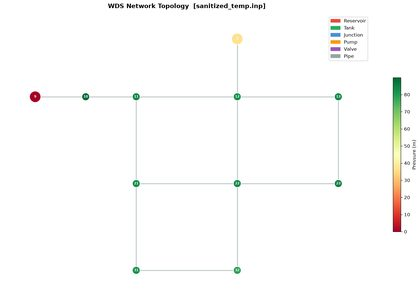
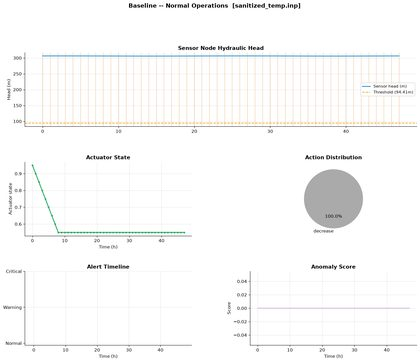
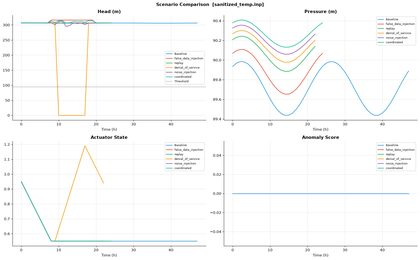
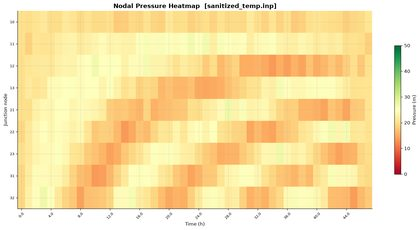
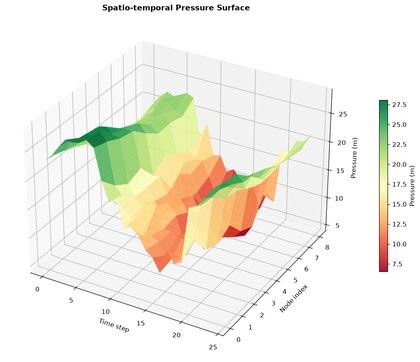
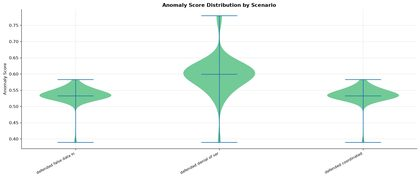
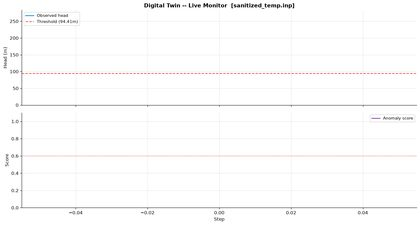
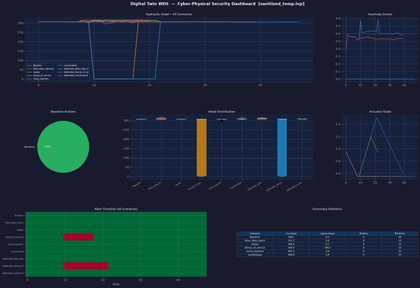
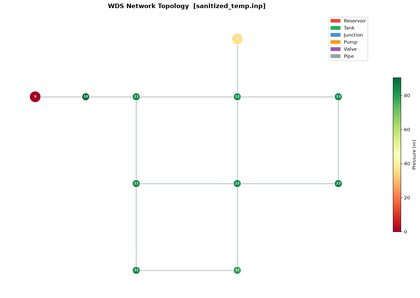
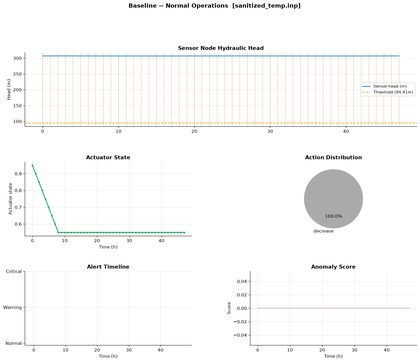
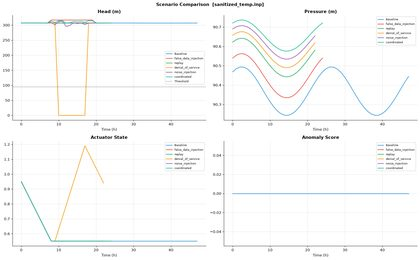
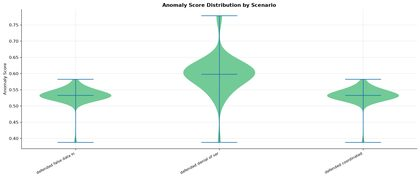

Showing 12 of 118 collected figures.


In [20]:
from IPython.display import HTML, display

PREVIEW_LIMIT = 12       # how many figures to render inline
PREVIEW_FILTER = ""      # substring match on relpath, e.g. "FDI_Defence" or "fig_0"

preview = [r for r in records
           if r["format"] in {"png", "jpg", "jpeg", "gif"}
           and PREVIEW_FILTER.lower() in r["relpath"].lower()][:PREVIEW_LIMIT]

if not preview:
    print("No raster figures match the preview filter.")
else:
    blocks = []
    for r in preview:
        uri = thumb_data_uri(FIGURE_DIR / r["relpath"], width=420)
        if not uri:
            continue
        blocks.append(
            '<div style="display:inline-block;vertical-align:top;'
            'margin:0 12px 16px 0;max-width:430px">'
            f'<img src="{uri}" style="width:100%;border:1px solid #ccc;border-radius:6px">'
            '<div style="font:11px/1.4 monospace;color:#666;margin-top:4px;'
            f'word-break:break-all">{_html.escape(r["relpath"])}</div></div>'
        )
    display(HTML("".join(blocks)))
    print(f"Showing {len(blocks)} of {len(records)} collected figures.")

---
## 10. Optional - regenerate figures by re-running the source notebooks

**Off by default.** The source notebooks train GANs, run EPANET/WNTR simulations and fit
detector suites; a full re-run costs hours and needs the complete dependency stack
(`torch`, `wntr`, `shap`, ...) plus `nbformat` + `nbclient`.

Turn this on only when you want figures regenerated from scratch rather than harvested.
Each notebook is executed with an injected hook that patches `matplotlib.pyplot.show` and
`Figure.savefig`, so **every** figure - including the ones the notebooks only `show()` and
never save - is written into `~/figure/rerun/<notebook>/`.

The original notebooks are never modified: execution happens on an in-memory copy.

In [21]:
RERUN_NOTEBOOKS = False             # <-- set True to re-execute (slow!)
RERUN_SELECTION = SOURCE_NOTEBOOKS  # or e.g. ["DT_WDS1.ipynb"]
RERUN_TIMEOUT = 60 * 60             # seconds allowed per cell
RERUN_ALLOW_ERRORS = True           # keep going past a failing cell

# Injected as the first cell of the in-memory copy of each notebook.
AUTOSAVE_HOOK = r"""
import os
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure

_AUTO_DIR = Path(os.environ["FIGURE_AUTOSAVE_DIR"])
_AUTO_DIR.mkdir(parents=True, exist_ok=True)
_auto_n = {"i": 0}
_seen = set()

def _auto_dump(fig, tag="show"):
    _auto_n["i"] += 1
    label = ""
    try:
        label = (fig._suptitle.get_text() if fig._suptitle
                 else (fig.axes[0].get_title() if fig.axes else ""))
    except Exception:
        pass
    label = "".join(c if c.isalnum() or c in "-_" else "_" for c in label)[:48].strip("_")
    name = f"auto_{_auto_n['i']:03d}_{tag}" + (f"_{label}" if label else "") + ".png"
    try:
        fig.savefig(_AUTO_DIR / name, dpi=200, bbox_inches="tight")
    except Exception as exc:
        print("[autosave] failed:", exc)

_orig_show = _plt.show
def _show(*a, **k):
    for num in _plt.get_fignums():
        _auto_dump(_plt.figure(num), "show")
    return _orig_show(*a, **k)
_plt.show = _show

_orig_savefig = _Figure.savefig
def _savefig(self, fname, *a, **k):
    out = _orig_savefig(self, fname, *a, **k)
    try:
        stem = Path(str(fname)).stem
        if stem not in _seen:
            _seen.add(stem)
            _orig_savefig(self, _AUTO_DIR / (stem + ".png"), dpi=200, bbox_inches="tight")
    except Exception:
        pass
    return out
_Figure.savefig = _savefig

print("[autosave] every figure ->", _AUTO_DIR)
"""


def rerun_notebook(nb_name: str) -> None:
    import nbformat
    from nbclient import NotebookClient

    nb_path = PROJECT_ROOT / nb_name
    out_dir = FIGURE_DIR / "rerun" / slugify(nb_path.stem)
    out_dir.mkdir(parents=True, exist_ok=True)

    nb = nbformat.read(nb_path, as_version=4)
    nb.cells.insert(0, nbformat.v4.new_code_cell(AUTOSAVE_HOOK))

    os.environ["FIGURE_AUTOSAVE_DIR"] = str(out_dir)
    client = NotebookClient(
        nb,
        timeout=RERUN_TIMEOUT,
        allow_errors=RERUN_ALLOW_ERRORS,
        kernel_name="python3",
        resources={"metadata": {"path": str(PROJECT_ROOT)}},
    )
    print(f"  executing {nb_name} ... (this can take a long time)")
    client.execute()
    print(f"  {nb_name}: {len(list(out_dir.glob('*.png')))} figure(s) -> {out_dir}")


if RERUN_NOTEBOOKS:
    try:
        import nbformat, nbclient  # noqa: F401
    except ImportError:
        print("Re-execution needs nbformat + nbclient:")
        print(f"   {sys.executable} -m pip install nbformat nbclient")
    else:
        for nb_name in RERUN_SELECTION:
            if not (PROJECT_ROOT / nb_name).exists():
                print(f"  [skip] {nb_name} - not found")
                continue
            try:
                rerun_notebook(nb_name)
            except Exception as exc:
                print(f"  [fail] {nb_name}: {type(exc).__name__}: {exc}")
        print("\nRe-run complete. Re-execute sections 4-8 to fold the new figures "
              "into the manifest and contact sheet.")
else:
    print("RERUN_NOTEBOOKS is False - figures were harvested, not regenerated.")
    print("Set RERUN_NOTEBOOKS = True above to re-execute the source notebooks.")

RERUN_NOTEBOOKS is False - figures were harvested, not regenerated.
Set RERUN_NOTEBOOKS = True above to re-execute the source notebooks.


---
## 11. Done

`~/figure` now contains:

```
~/figure/
|-- index.html                  <- contact sheet, open this first
|-- manifest.csv                <- one row per figure, with provenance + SHA-256
|-- manifest.json
|-- duplicates.csv             <- byte-identical copies that were not re-collected
|-- DT_WDS1/                    <- Net1 digital-twin figures (from notebook cells)
|-- DT_WDS2/                    <- Net2
|-- DT_WDS3/                    <- Net3
|-- FDI_Attack1/                <- GAN attack figures (from notebook cells)
|-- FDI_Defence_WDS1/
|-- dt_wds_output_figures/      <- savefig() output from the digital-twin notebooks
|-- results_visualizations/     <- 300-dpi PNG + vector PDF publication figures
`-- rerun/                      <- only if section 10 was enabled
```

**Re-running this notebook is safe.** Hash dedupe means already-collected figures are
skipped, and nothing is overwritten - a changed figure with the same name lands as
`..._v2.png`. To start from scratch, set `CLEAN_DESTINATION = True` in section 1.

**Picking figures for a manuscript:** prefer the `.pdf` files under
`results_visualizations/` (vector, 300 dpi). For the digital-twin figures, prefer the
notebook-embedded PNGs under `DT_WDS1/2/3/` - `DT_WDS1/2/3.ipynb` all write to the same
`dt_wds_output/figures/` folder and overwrite each other, so only the embedded copies
preserve all three networks.